In [ ]:
# Phase 2 Data Cleaning & Preprocessing

In [4]:
import pandas as pd 
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Load directly from excel 
df =pd.read_excel(r'D:\ayush saxena\AYUSH\AYUSH_CV\Analyst_Project\sample_-_superstore(AutoRecovered).xlsx', sheet_name='Orders')

print("File Loaded!")
print("Rows:", len(df))
print("Columns:", len(df.columns))
print("\nColumn names:")
for col in df.columns:
    print(" -", col)

File Loaded!
Rows: 10194
Columns: 21

Column names:
 - Row ID
 - Order ID
 - Order Date
 - Ship Date
 - Ship Mode
 - Customer ID
 - Customer Name
 - Segment
 - Country/Region
 - City
 - State/Province
 - Postal Code
 - Region
 - Product ID
 - Category
 - Sub-Category
 - Product Name
 - Sales
 - Quantity
 - Discount
 - Profit


In [7]:
# Data Quality Check 

print("=== MISSING VALUES ===")
print(df.isnull().sum())

print("\n=== DUPLICATES ===")
print(df.dtypes)

print("\n=== DUPLICATES ===")
print("Duplicate rows:", df.duplicated().sum())

=== MISSING VALUES ===
Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country/Region    0
City              0
State/Province    0
Postal Code       0
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Quantity          0
Discount          0
Profit            0
dtype: int64

=== DUPLICATES ===
Row ID                     int64
Order ID                  object
Order Date        datetime64[ns]
Ship Date         datetime64[ns]
Ship Mode                 object
Customer ID               object
Customer Name             object
Segment                   object
Country/Region            object
City                      object
State/Province            object
Postal Code               object
Region                    object
Product ID                object
Category                  object
Sub-Category              obj

In [8]:
# Fix Dates + add new columns 

df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

df['Profit Margin %'] = (df['Profit'] / df['Sales'] * 100).round(2)
df['Year']            = df['Order Date'].dt.year
df['Month']           = df['Order Date'].dt.month
df['Month Name']      = df['Order Date'].dt.strftime('%b')
df['Quarter']         = 'Q' + df['Order Date'].dt.quarter.astype(str)
df['Ship Days']       = (df['Ship Date'] - df['Order Date']).dt.days
df['Is_Loss']         = df['Profit'] < 0
df['High_Discount']   = df['Discount'] > 0.2

print("New Columns Added!")
print("New Shape:", df.shape)

New Columns Added!
New Shape: (10194, 29)


In [9]:
# Cell 4 — Summary + save
print("=== BUSINESS SUMMARY ===")
print(f"Total Sales:    ${df['Sales'].sum():,.0f}")
print(f"Total Profit:   ${df['Profit'].sum():,.0f}")
print(f"Loss Orders:     {df['Is_Loss'].sum()} ({df['Is_Loss'].mean()*100:.1f}%)")
print(f"Avg Ship Days:   {df['Ship Days'].mean():.1f} days")

print("\n=== MARGIN BY CATEGORY ===")
print(df.groupby('Category')['Profit Margin %'].mean().round(1))

df.to_csv(r'D:\ayush saxena\AYUSH\AYUSH_CV\Analyst_Project\superstore_clean.csv', index=False)
print("\n✅ Clean file saved!")

=== BUSINESS SUMMARY ===
Total Sales:    $2,326,534
Total Profit:   $292,297
Loss Orders:     1901 (18.6%)
Avg Ship Days:   4.0 days

=== MARGIN BY CATEGORY ===
Category
Furniture           4.3
Office Supplies    14.0
Technology         15.8
Name: Profit Margin %, dtype: float64

✅ Clean file saved!


In [11]:
# Phase 3 — EDA Charts 

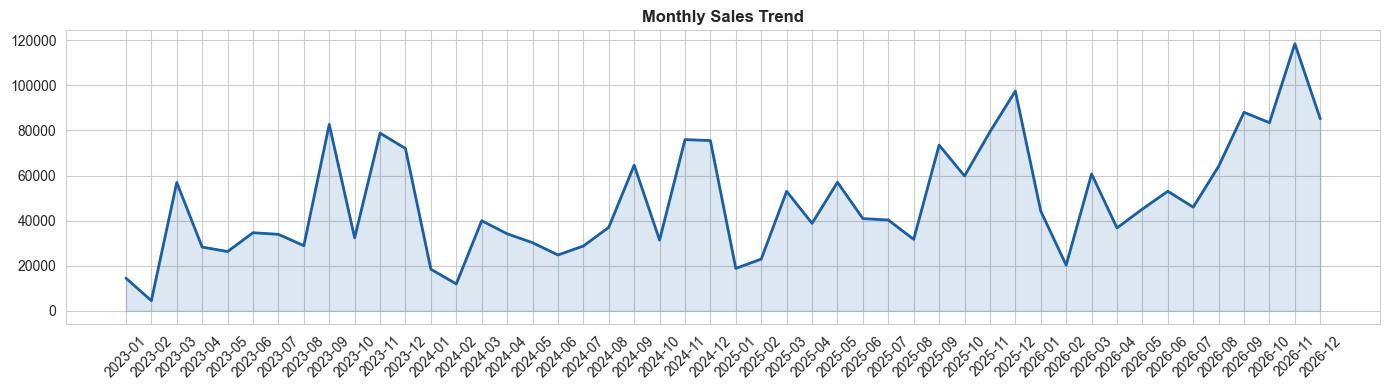

✅ 1_monthly_trend saved


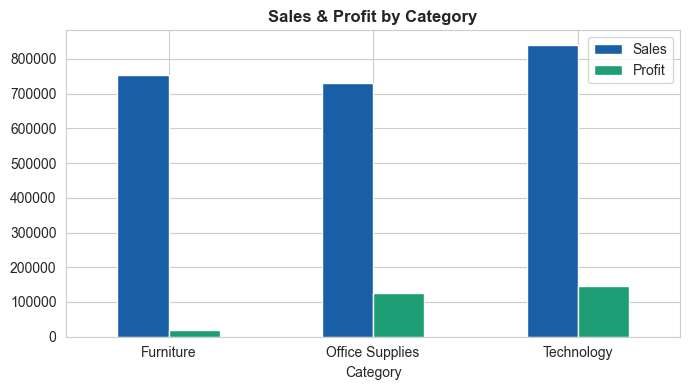

✅ 2_category saved


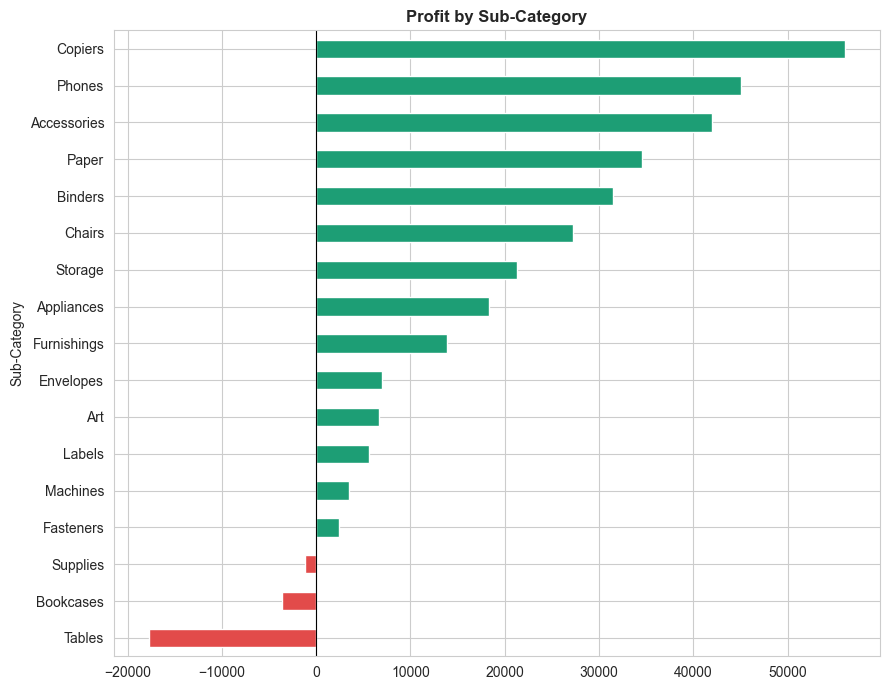

✅ 3_subcategory saved


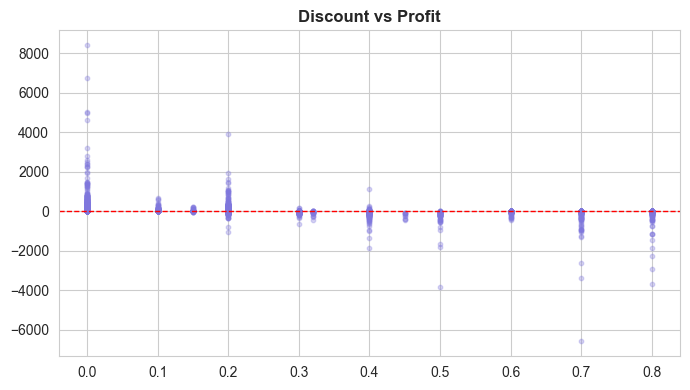

✅ 4_discount_profit saved


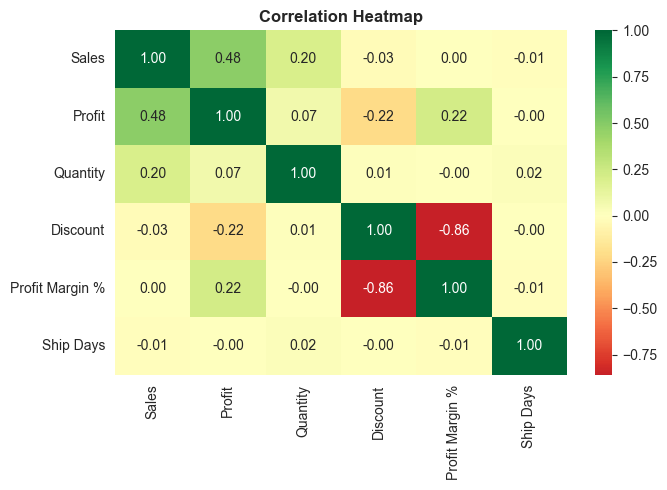

✅ 5_heatmap saved


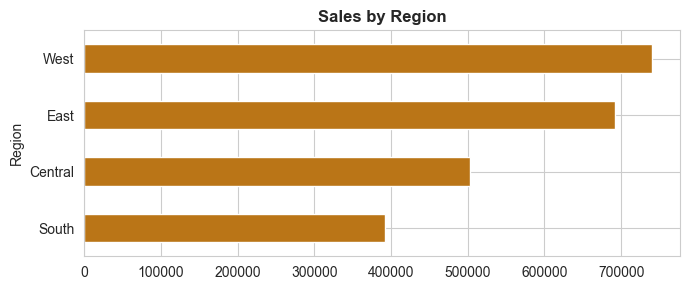

✅ 6_region saved


In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_style("whitegrid")
path = r'D:\ayush saxena\AYUSH\AYUSH_CV\Analyst_Project\charts'
os.makedirs(path, exist_ok=True)

def save(name):
    plt.tight_layout()
    plt.savefig(f'{path}\\{name}.png', dpi=150)
    plt.show()
    print(f"✅ {name} saved")

# 1 — Monthly trend
monthly = df.groupby(df['Order Date'].dt.to_period('M'))['Sales'].sum()
fig, ax = plt.subplots(figsize=(14,4))
ax.plot(monthly.index.astype(str), monthly.values, color='#185FA5', lw=2)
ax.fill_between(monthly.index.astype(str), monthly.values, alpha=0.15, color='#185FA5')
ax.set_title('Monthly Sales Trend', fontweight='bold')
plt.xticks(rotation=45)
save('1_monthly_trend')

# 2 — Category
df.groupby('Category')[['Sales','Profit']].sum().plot(kind='bar', figsize=(7,4), color=['#185FA5','#1D9E75'])
plt.title('Sales & Profit by Category', fontweight='bold'); plt.xticks(rotation=0)
save('2_category')

# 3 — Sub-category profit
sub = df.groupby('Sub-Category')['Profit'].sum().sort_values()
sub.plot(kind='barh', figsize=(9,7), color=['#E24B4A' if x<0 else '#1D9E75' for x in sub])
plt.axvline(0, color='black', lw=0.8); plt.title('Profit by Sub-Category', fontweight='bold')
save('3_subcategory')

# 4 — Discount vs Profit
plt.figure(figsize=(7,4))
plt.scatter(df['Discount'], df['Profit'], alpha=0.3, color='#7F77DD', s=10)
plt.axhline(0, color='red', lw=1, linestyle='--'); plt.title('Discount vs Profit', fontweight='bold')
save('4_discount_profit')

# 5 — Heatmap
plt.figure(figsize=(7,5))
sns.heatmap(df[['Sales','Profit','Quantity','Discount','Profit Margin %','Ship Days']].corr().round(2),
            annot=True, cmap='RdYlGn', center=0, fmt='.2f')
plt.title('Correlation Heatmap', fontweight='bold')
save('5_heatmap')

# 6 — Region
df.groupby('Region')['Sales'].sum().sort_values().plot(kind='barh', figsize=(7,3), color='#BA7517')
plt.title('Sales by Region', fontweight='bold')
save('6_region')
